In [3]:
pip install torch torchvision pillow numpy scikit-learn

In [4]:
import os
import random
import numpy as np

from PIL import Image
from torchvision import datasets
from sklearn.model_selection import train_test_split

In [5]:
mnist = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

mnist_images = mnist.data.numpy()
mnist_labels = mnist.targets.numpy()

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 472kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.29MB/s]


In [6]:
sizes = {
    "small": 28,
    "large": 56
}

colors = {
    "red": (255,0,0),
    "blue": (0,0,255),
    "green": (0,128,0),
    "black": (0,0,0)
}

In [7]:
def generate_number():

    length = random.randint(1,4)

    digits = []

    for _ in range(length):

        idx = random.randint(0, len(mnist_images)-1)

        digit_img = mnist_images[idx]

        digit_label = mnist_labels[idx]

        digits.append((digit_img, digit_label))

    return digits

In [8]:
def combine_digits(digits, size):

    resized_digits = []

    for img, label in digits:

        pil_img = Image.fromarray(img)

        pil_img = pil_img.resize(
            (size, size)
        )

        resized_digits.append(pil_img)

    width = size * len(resized_digits)

    combined = Image.new(
        "L",
        (width, size),
        color=0
    )

    x_offset = 0

    for digit in resized_digits:

        combined.paste(
            digit,
            (x_offset, 0)
        )

        x_offset += size

    return combined

In [9]:
def apply_color(image, color):

    image = image.convert("RGBA")

    data = np.array(image)

    r,g,b = color

    red, green, blue, alpha = data.T

    mask = red > 0

    data[..., :-1][mask.T] = (r,g,b)

    return Image.fromarray(data)

In [10]:
def create_sentence(size_name, color_name, digits):

    number = "".join(
        str(label)
        for _, label in digits
    )

    sentence = f"{size_name} {color_name} {number}"

    return sentence

In [11]:
dataset = []

for i in range(1000):

    size_name = random.choice(
        list(sizes.keys())
    )

    color_name = random.choice(
        list(colors.keys())
    )

    size_value = sizes[size_name]

    color_value = colors[color_name]

    digits = generate_number()

    number_img = combine_digits(
        digits,
        size_value
    )

    colored_img = apply_color(
        number_img,
        color_value
    )

    sentence = create_sentence(
        size_name,
        color_name,
        digits
    )

    dataset.append(
        (colored_img, sentence)
    )

In [12]:
indices = list(range(len(dataset)))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42
)

In [13]:
def save_split(name, indices):

    os.makedirs(
        f"dataset/{name}",
        exist_ok=True
    )

    label_file = open(
        f"dataset/{name}/labels.txt",
        "w"
    )

    for i, idx in enumerate(indices):

        img, sentence = dataset[idx]

        filename = f"img_{i}.png"

        path = f"dataset/{name}/{filename}"

        img.save(path)

        label_file.write(
            f"{filename},{sentence}\n"
        )

    label_file.close()

save_split("train", train_idx)
save_split("val", val_idx)
save_split("test", test_idx)

In [14]:
import os

print(os.listdir("dataset"))

['train', 'test', 'val']


In [15]:
print(os.listdir("dataset/train")[:10])

['img_452.png', 'img_377.png', 'img_678.png', 'img_787.png', 'img_119.png', 'img_77.png', 'img_585.png', 'img_57.png', 'img_602.png', 'img_87.png']


(np.float64(-0.5), np.float64(55.5), np.float64(27.5), np.float64(-0.5))

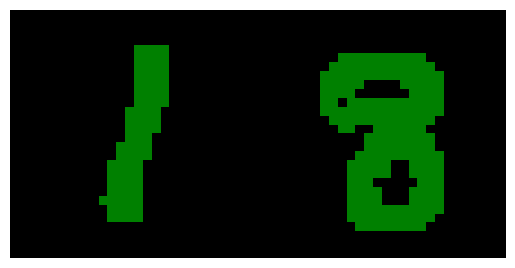

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("dataset/train/img_0.png")

plt.imshow(img)
plt.axis("off")

In [17]:
import os

print("Train:", len(os.listdir("dataset/train")))
print("Val:", len(os.listdir("dataset/val")))
print("Test:", len(os.listdir("dataset/test")))

Train: 801
Val: 101
Test: 101


In [18]:
with open("dataset/train/labels.txt") as f:
    for i in range(5):
        print(f.readline())

img_0.png,small green 18

img_1.png,large black 20

img_2.png,large black 5822

img_3.png,small blue 1

img_4.png,large blue 9638



In [20]:
import os

print(os.listdir())

['.config', 'dataset', 'data', 'sample_data']


In [21]:
!zip -r dataset.zip dataset

  adding: dataset/ (stored 0%)
  adding: dataset/train/ (stored 0%)
  adding: dataset/train/img_452.png (stored 0%)
  adding: dataset/train/img_377.png (deflated 27%)
  adding: dataset/train/img_678.png (stored 0%)
  adding: dataset/train/img_787.png (deflated 1%)
  adding: dataset/train/img_119.png (deflated 5%)
  adding: dataset/train/img_77.png (deflated 0%)
  adding: dataset/train/img_585.png (stored 0%)
  adding: dataset/train/img_57.png (stored 0%)
  adding: dataset/train/img_602.png (deflated 57%)
  adding: dataset/train/img_87.png (deflated 32%)
  adding: dataset/train/img_53.png (stored 0%)
  adding: dataset/train/img_36.png (stored 0%)
  adding: dataset/train/img_411.png (deflated 1%)
  adding: dataset/train/img_154.png (stored 0%)
  adding: dataset/train/img_189.png (stored 0%)
  adding: dataset/train/img_420.png (stored 0%)
  adding: dataset/train/img_701.png (stored 0%)
  adding: dataset/train/img_19.png (stored 0%)
  adding: dataset/train/img_332.png (deflated 1%)
  addin

In [22]:
from google.colab import files
files.download("dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
!git clone https://github.com/rmkhan1999/Neural-Network-to-Describe-Simple-Pictures-Group-40.git

Cloning into 'Neural-Network-to-Describe-Simple-Pictures-Group-40'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 4.53 KiB | 2.27 MiB/s, done.


In [24]:
import os
print(os.listdir())

['.config', 'Neural-Network-to-Describe-Simple-Pictures-Group-40', 'dataset', 'dataset.zip', 'data', 'sample_data']


In [25]:
import shutil

shutil.copy(
    "dataset.zip",
    "Neural-Network-to-Describe-Simple-Pictures-Group-40/"
)

'Neural-Network-to-Describe-Simple-Pictures-Group-40/dataset.zip'

In [27]:
import os
print(os.listdir())

['.config', 'Neural-Network-to-Describe-Simple-Pictures-Group-40', 'dataset', 'dataset.zip', 'data', 'sample_data']
